In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
df.shape

(3999, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
df.isnull().sum()


ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [7]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


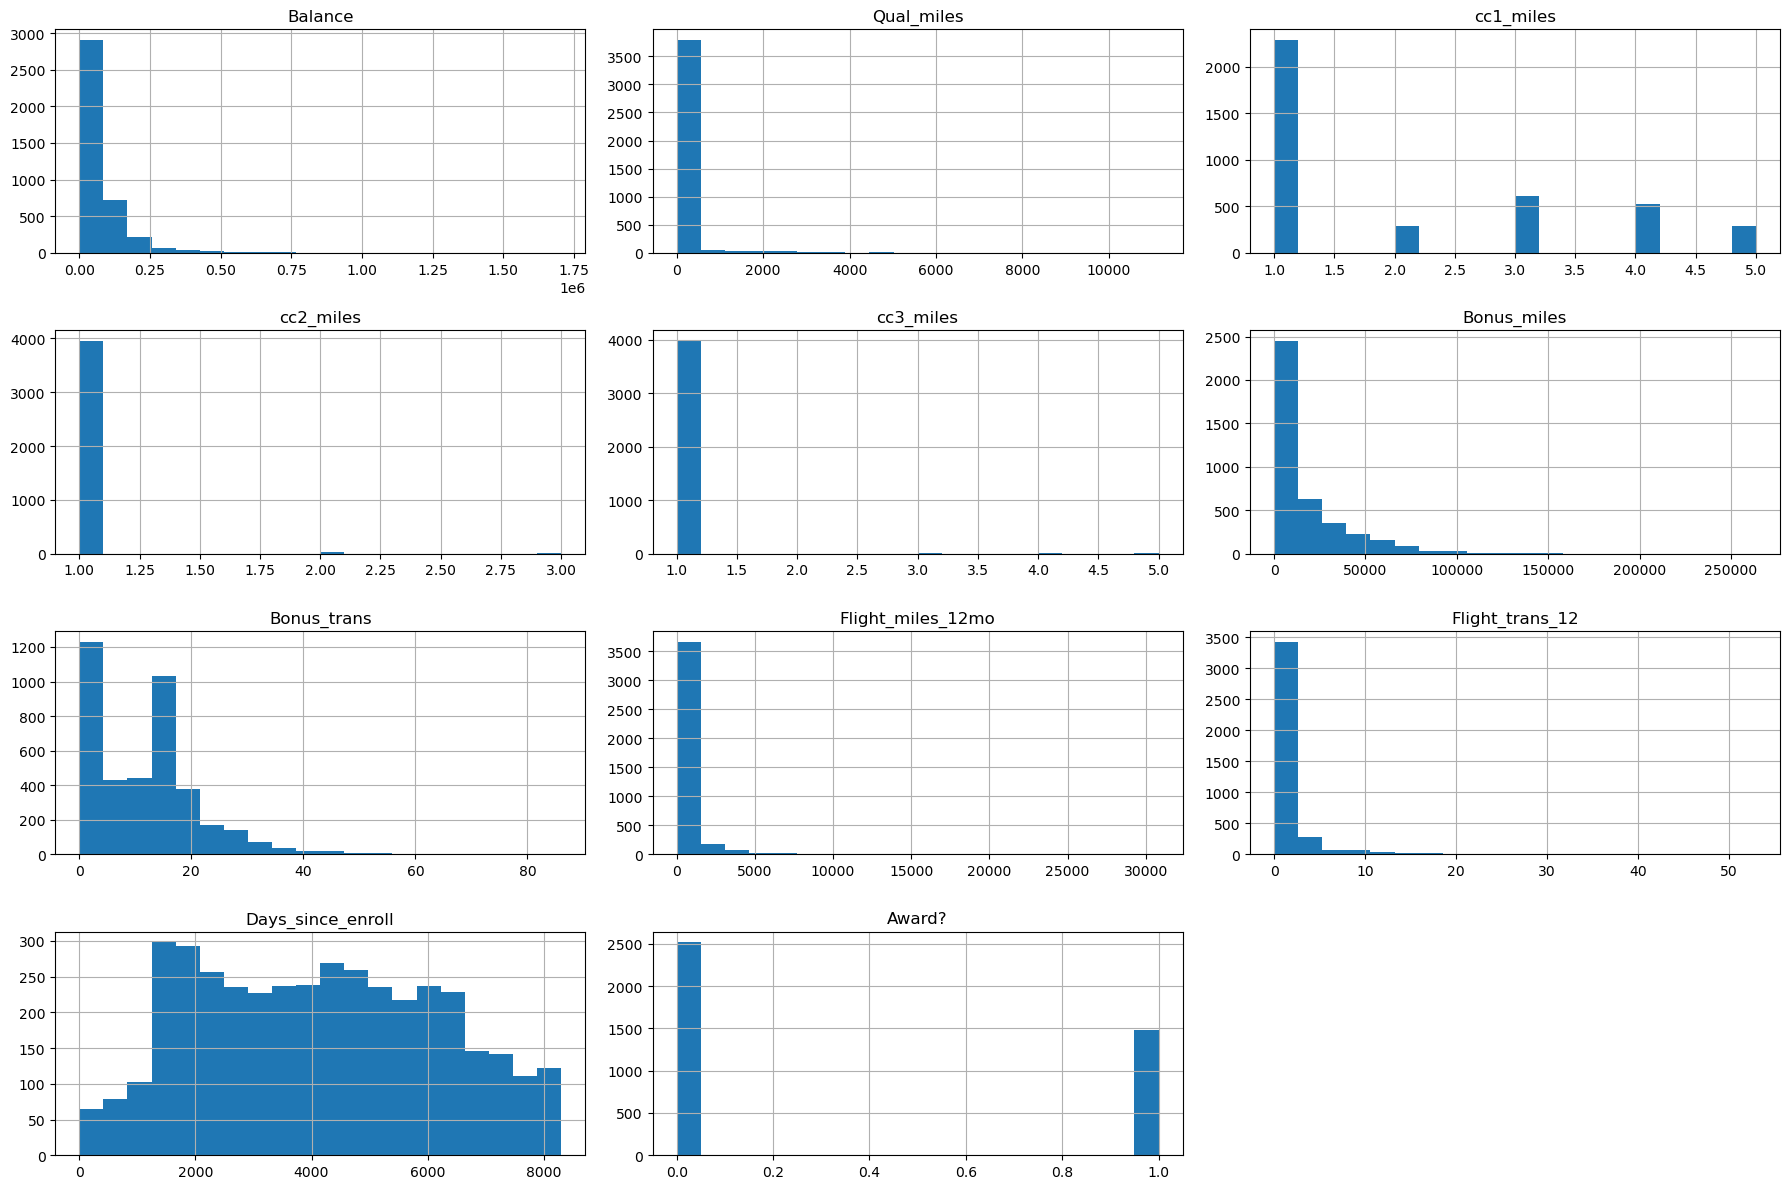

In [8]:
df.drop('ID#',axis=1).hist(bins=20,figsize=(18, 12))
plt.tight_layout()
plt.show()

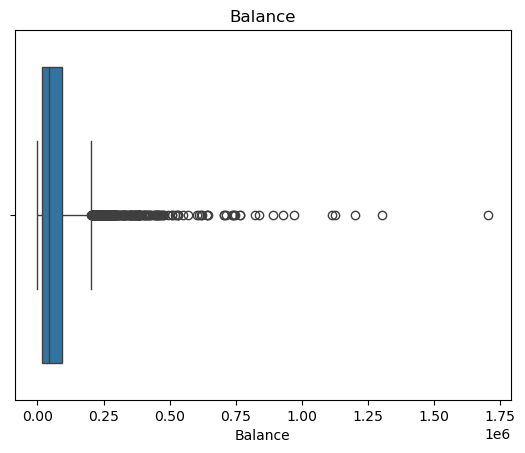

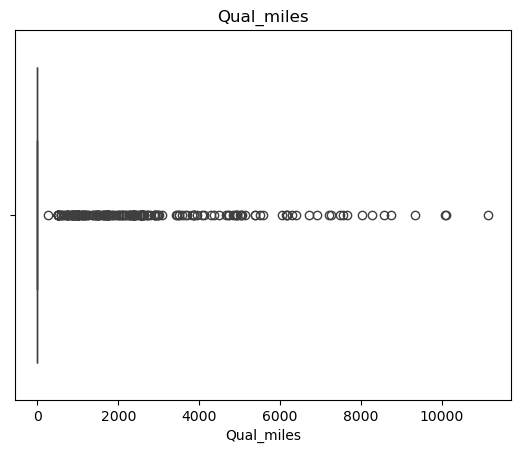

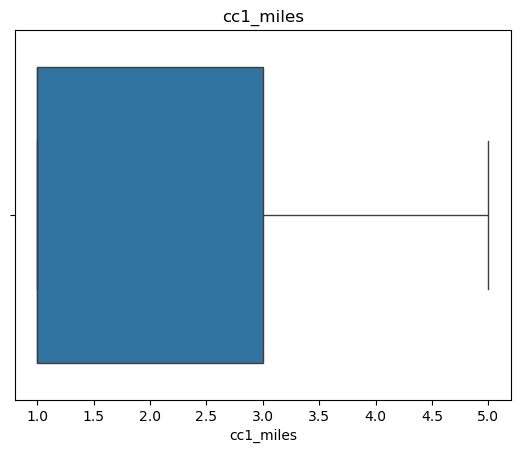

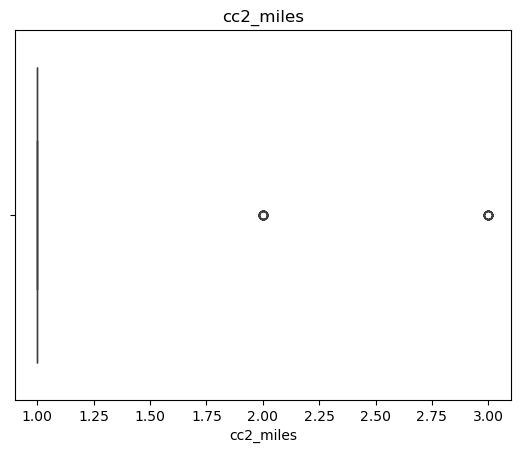

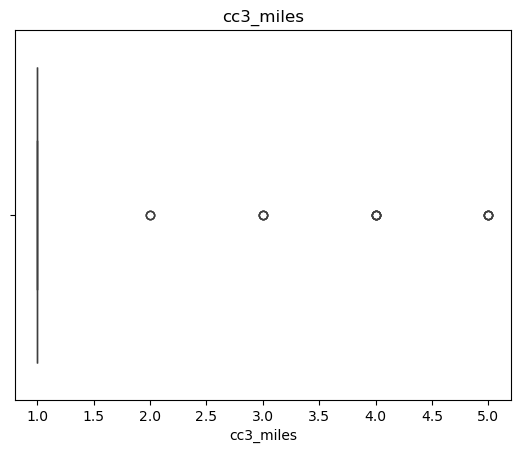

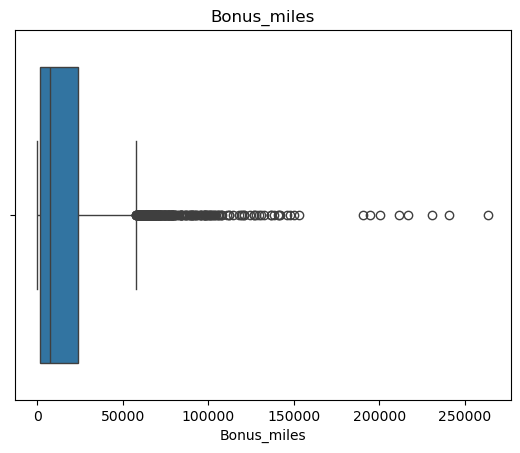

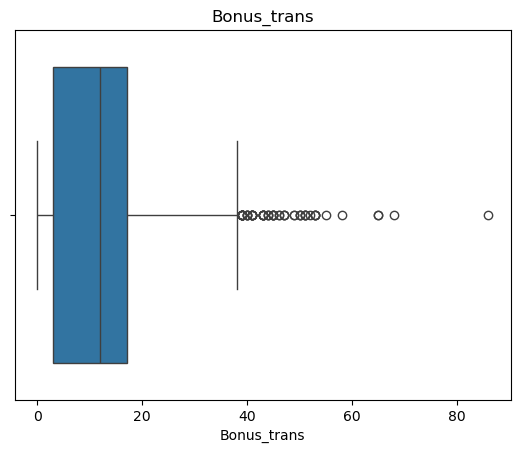

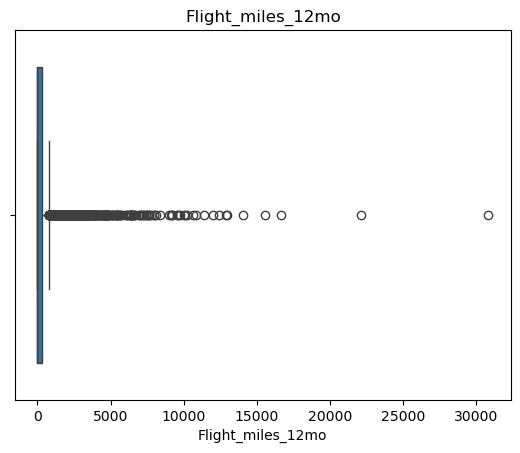

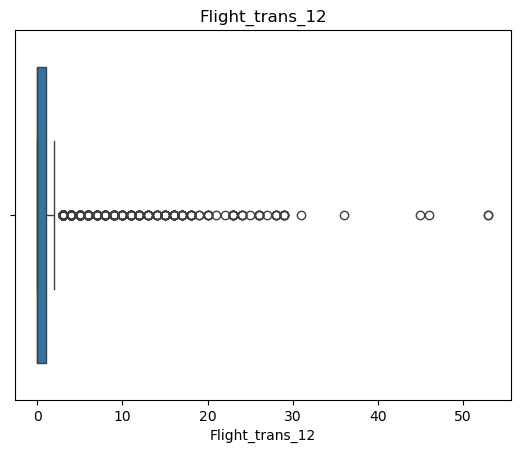

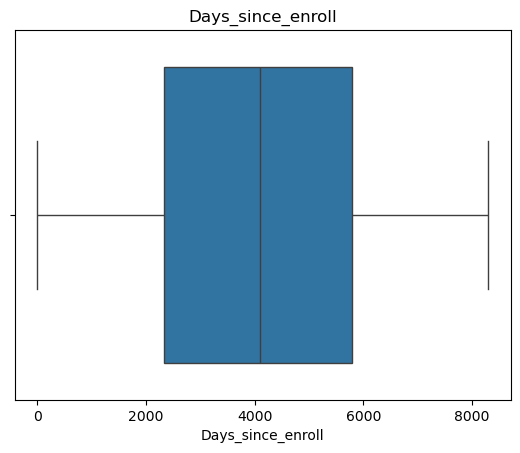

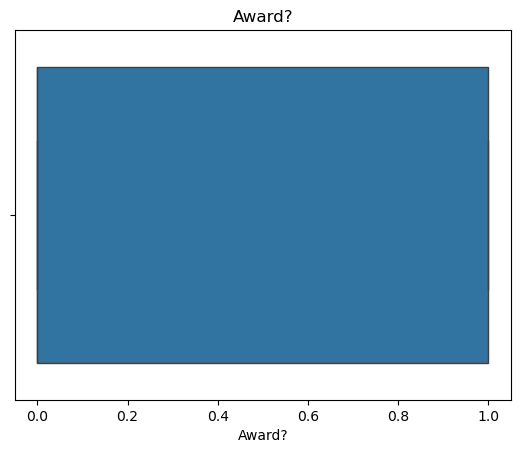

In [9]:
for col in df.drop('ID#',axis=1).columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

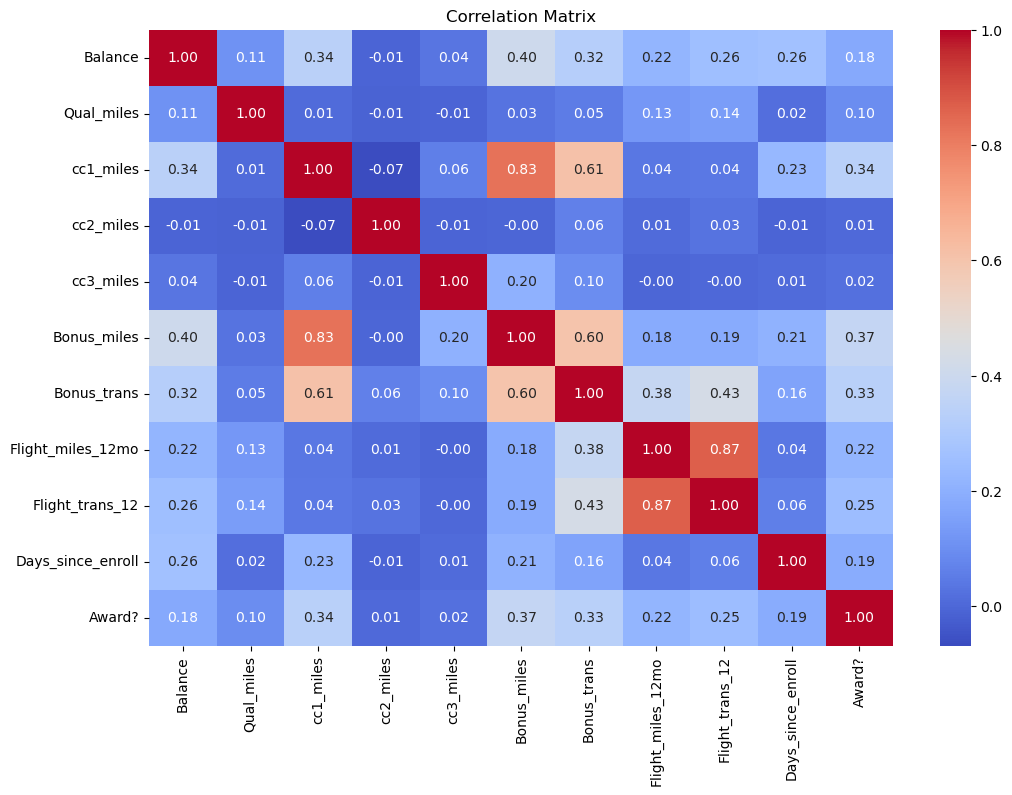

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop('ID#',axis=1).corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Balance, Bonus_miles and Days_since_enroll have high variance and outliers. Scaling is needed before clustering.

In [11]:
from sklearn.preprocessing import StandardScaler
X=df.drop('ID#',axis=1)
scaler=StandardScaler()
scaled=scaler.fit_transform(X)

# Implementing Clustering Algorithms

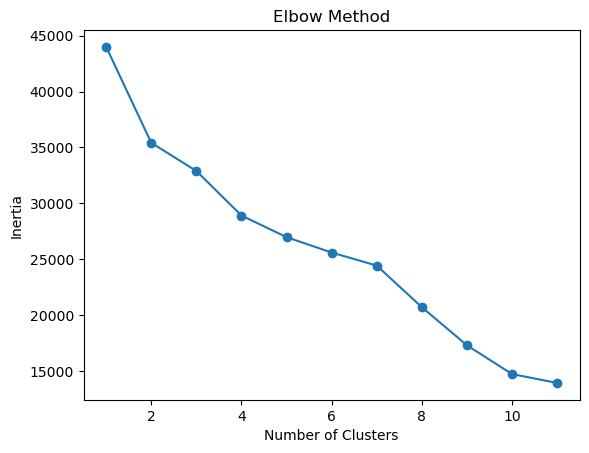

In [12]:
from sklearn.cluster import KMeans
inertia=[]
for i in range(1,12):
    km=KMeans(n_clusters=i,random_state=42)
    km.fit(scaled)
    inertia.append(km.inertia_)
plt.plot(range(1,12),inertia,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [13]:
kmeans=KMeans(n_clusters=4,random_state=42)
kmeans_labels=kmeans.fit_predict(scaled)

In [14]:
from sklearn.neighbors import NearestNeighbors

In [15]:
nn=NearestNeighbors(n_neighbors=10)
nn.fit(scaled)
distances,_=nn.kneighbors(scaled)
distances=np.sort(distances[:, 1])

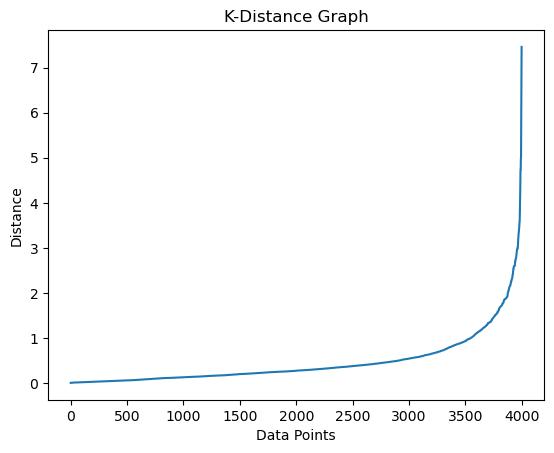

In [16]:
plt.plot(distances)
plt.title('K-Distance Graph')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

In [17]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=2,min_samples=9)
dbscan_labels=dbscan.fit_predict(scaled)

In [18]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering


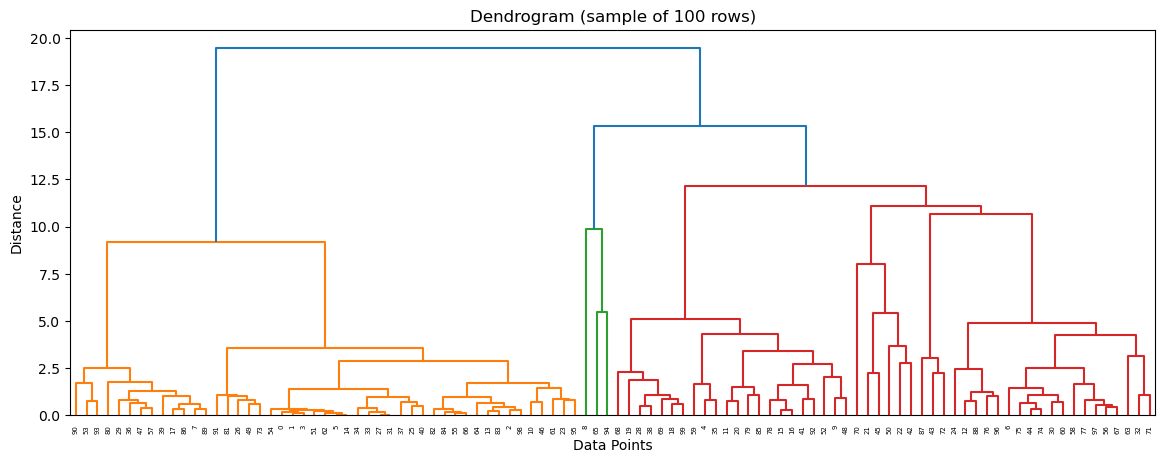

In [19]:
sample=scaled[:100]
plt.figure(figsize=(14,5))
sch.dendrogram(sch.linkage(sample,method='ward'))
plt.title('Dendrogram (sample of 100 rows)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

In [20]:
hc=AgglomerativeClustering(n_clusters=4,metric='euclidean',linkage='ward')
hc_labels=hc.fit_predict(scaled)

# Visualization

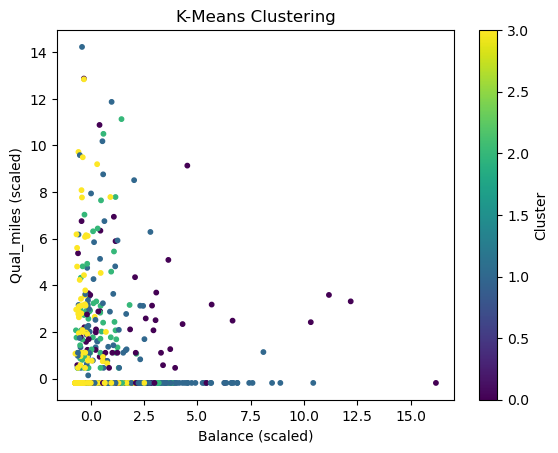

In [21]:
plt.scatter(scaled[:,0],scaled[:,1],c=kmeans_labels,cmap='viridis',s=10)
plt.title('K-Means Clustering')
plt.xlabel('Balance (scaled)')
plt.ylabel('Qual_miles (scaled)')
plt.colorbar(label='Cluster')
plt.show()

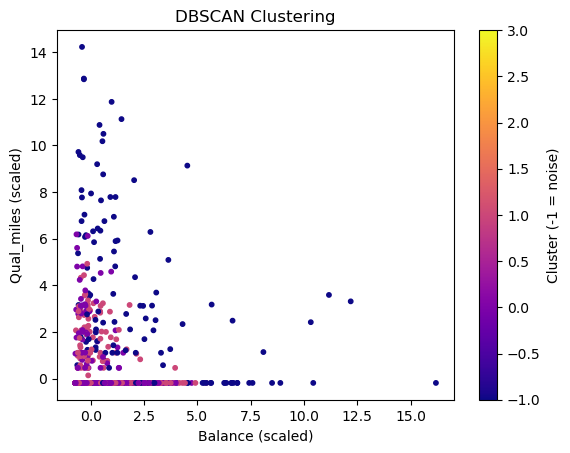

In [22]:
plt.scatter(scaled[:,0],scaled[:,1],c=dbscan_labels,cmap='plasma',s=10)
plt.title('DBSCAN Clustering')
plt.xlabel('Balance (scaled)')
plt.ylabel('Qual_miles (scaled)')
plt.colorbar(label='Cluster (-1 = noise)')
plt.show()

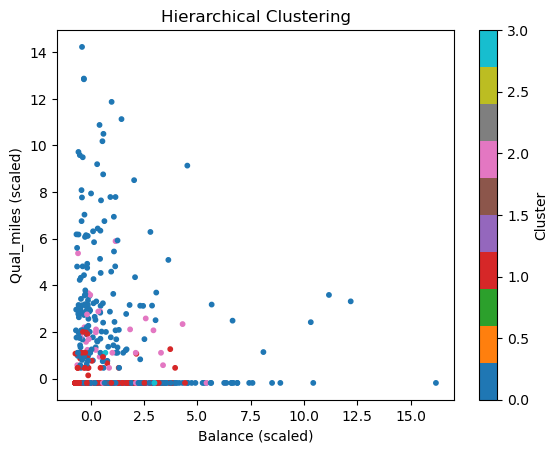

In [23]:
plt.scatter(scaled[:,0],scaled[:,1],c=hc_labels,cmap='tab10',s=10)
plt.title('Hierarchical Clustering')
plt.xlabel('Balance (scaled)')
plt.ylabel('Qual_miles (scaled)')
plt.colorbar(label='Cluster')
plt.show()

# Evaluation and Performance Metrics

In [25]:
from sklearn.metrics import silhouette_score

In [26]:
sil_kmeans=silhouette_score(scaled,kmeans_labels)
print("K-Means Silhouette Score:", round(sil_kmeans,4))

K-Means Silhouette Score: 0.1907


In [27]:
mask=dbscan_labels != -1
sil_dbscan=silhouette_score(scaled[mask],dbscan_labels[mask])
print("DBSCAN Silhouette Score:",round(sil_dbscan,4))

DBSCAN Silhouette Score: 0.288


In [28]:
sil_hc=silhouette_score(scaled,hc_labels)
print("Hierarchical Silhouette Score:",round(sil_hc,4))

Hierarchical Silhouette Score: 0.3081


# K-Means gave the best silhouette score. DBSCAN also found noise points — customers who don't fit any cluster. Hierarchical clustering showed the structure well through the dendrogram.

# Overall K-Means worked best here. The airline can use these clusters to target different customer groups — frequent flyers and inactive members need very different offers.